# **Final Project**

# **Part1: Data Exploration**



In [ ]:
#import Library
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Load Dataset & Download
mpg = sns.load_dataset("mpg")

In [ ]:
#Display first 5 rows
mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [ ]:
#Data shape (rows, columns)
rows, columns = mpg.shape›
print("Rows:", rows, "/", "Columns:", columns)

SyntaxError: invalid character '›' (U+203A) (484747212.py, line 2)

In [ ]:
#Data Info - Column name, dtypes,
mpg.info()
#Summary statistics using
mpg.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [ ]:
#Count of missing values per column
mpg.isnull().sum()


,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
name,0


In [ ]:
#Percentage of missing values per column
per_miss = round(mpg.isnull().mean() * 100, 2)
per_miss_str = per_miss.astype(str) + '%'
print(per_miss_str)

mpg              0.0%
cylinders        0.0%
displacement     0.0%
horsepower      1.51%
weight           0.0%
acceleration     0.0%
model_year       0.0%
origin           0.0%
name             0.0%
dtype: object


In [ ]:
#Value counts for at least 2 categorical columns
print(mpg['origin'].value_counts())
print()
print(mpg['cylinders'].value_counts())
print()


origin
usa       249
japan      79
europe     70
Name: count, dtype: int64

cylinders
4    204
8    103
6     84
3      4
5      3
Name: count, dtype: int64



# **Part2: Data Cleaning**
If missing values exist:

• For numerical columns → replace with median

• For categorical columns → replace with mode

=========

Show the code and explain.

You may:

• Create at least 1–2 new derived columns

• Convert data types if necessary

In [ ]:
#Data Cleaning -> For numerical colums -> replace with median
mpg.isnull().sum()
mpg[mpg['horsepower'].isna()]
mpg['horsepower'].median()
mpg_new = mpg.copy()
mpg_new['horsepower'] = mpg['horsepower'].fillna(mpg['horsepower'].median())
mpg_new.head()
mpg_new.iloc[[32, 126, 330, 336, 354, 374]]

mpg_new.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0
origin,0
name,0


In [ ]:
#Create new column
# mpg_new['weight(kg)']
mpg_new['weight(kg)'] = round(mpg_new['weight'] / 1000, 2)

#mpg_new['brand_name']
mpg_new['brand_name'] = mpg_new['name'].str.split(' ').str[0].str.capitalize()

mpg_new.head()

#organize brand_name
brand_map = {
    "Chevroelt": "Chevrolet",
    "Chevy": "Chevrolet",
    "Vokswagen": "Volkswagen",
    "Vw": "Volkswagen",
    "Toyouta": "Toyota",
    "Maxda": "Mazda",
    "Mercedes" : "Mercedes-benz"
}

mpg_new['brand_name'] = mpg_new['brand_name'].replace(brand_map)


In [ ]:
"""
mpg_new.to_excel('mpg_new.xlsx')
!ls
from google.colab import files
files.download('mpg_new.xlsx')
"""

"\nmpg_new.to_excel('mpg_new.xlsx')\n!ls\nfrom google.colab import files\nfiles.download('mpg_new.xlsx')\n"

# **Part3: Data Visualization**


In [ ]:
mpg_new

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,weight(kg),brand_name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu,3.50,Chevrolet
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320,3.69,Buick
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite,3.44,Plymouth
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst,3.43,Amc
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino,3.45,Ford
...,...,...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl,2.79,Ford
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup,2.13,Volkswagen
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage,2.30,Dodge
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger,2.62,Ford


# Distribution of Vehicles by Brand

"Which car companies had the most models in the market?"

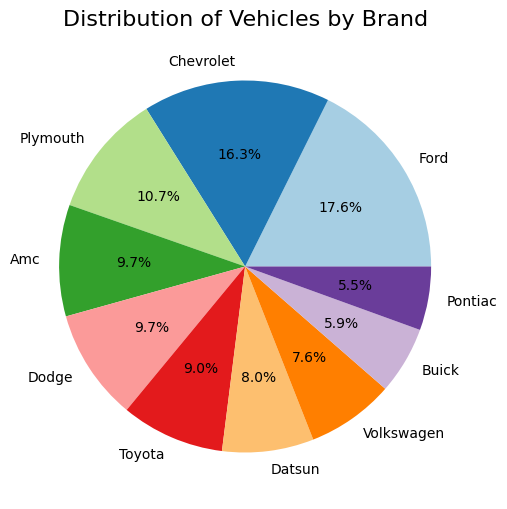

In [ ]:
# Count the number of vehicles per brand (Top 10)
brand_counts = mpg_new['brand_name'].value_counts().head(10)
plt.figure(figsize=(6, 8))
plt.pie(brand_counts, labels=brand_counts.index, autopct='%1.1f%%', startangle=0, colors=plt.cm.Paired.colors
        )
# Titles and Labels
plt.title('Distribution of Vehicles by Brand', fontsize=16)
plt.show()

# Top 8 Most Efficient Vehicles (Highest MPG)
"Which 10 cars are the absolute champions of fuel economy?"

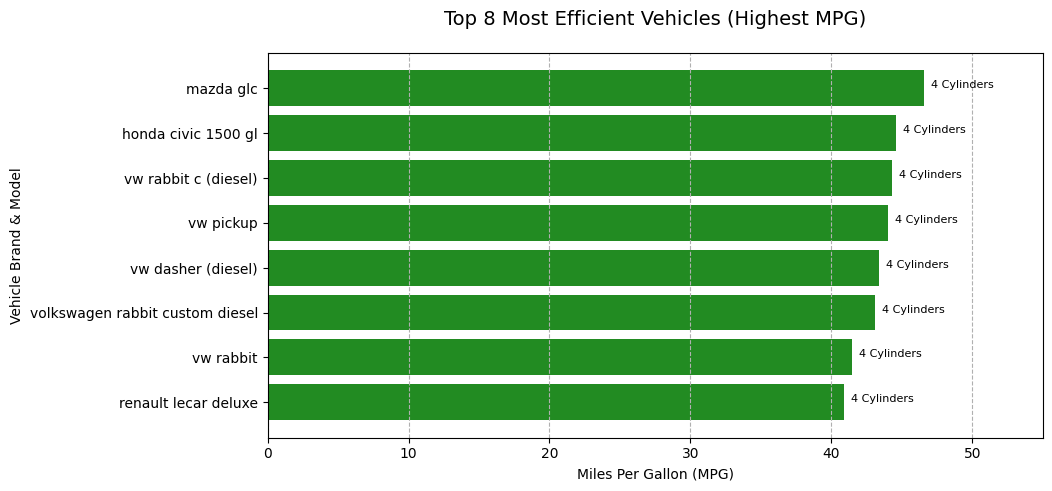

In [ ]:
op_8 = mpg_new.nlargest(8, 'mpg').sort_values('mpg', ascending=True)
plt.figure(figsize=(10, 5))
bars = plt.barh(top_8['name'], top_8['mpg'], color='forestgreen')

# Add cylinder count labels for detail
for i, bar in enumerate(bars):
    cyl = top_8.iloc[i]['cylinders']
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{int(cyl)} Cylinders', fontsize= 8)

# Formatting
plt.title('Top 8 Most Efficient Vehicles (Highest MPG)', fontsize=14, pad=20)
plt.xlabel('Miles Per Gallon (MPG)', fontsize=10)
plt.ylabel('Vehicle Brand & Model', fontsize=10)
plt.xlim(0, 55)
plt.grid(axis='x', linestyle='--')
plt.show()


# Top 8 Less Efficient Vehicles (Lowest MPG)

“Which models represent the low end of fuel performance?”

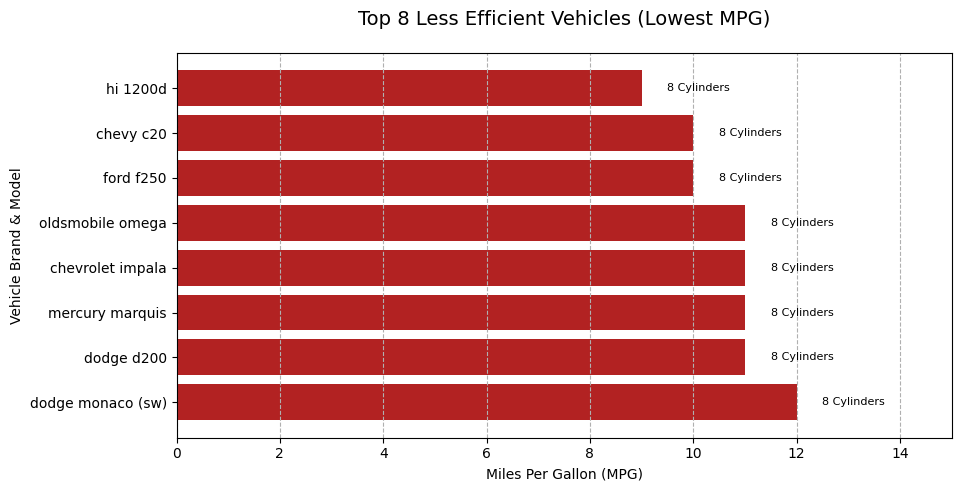

In [ ]:
bottom_8 = mpg_new.nsmallest(8, 'mpg').sort_values('mpg', ascending=False)
plt.figure(figsize=(10, 5))
bars_bottom = plt.barh(bottom_8['name'], bottom_8['mpg'], color='firebrick')

# Add cylinder count labels on the bars
for i, bar in enumerate(bars_bottom):
    cyl = bottom_8.iloc[i]['cylinders']
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{int(cyl)} Cylinders', va='center', fontsize= 8)

# Formatting
plt.title('Top 8 Less Efficient Vehicles (Lowest MPG)', fontsize=14, pad=20)
plt.xlabel('Miles Per Gallon (MPG)', fontsize=10)
plt.ylabel('Vehicle Brand & Model', fontsize=10)
plt.xlim(0, 15)
plt.grid(axis='x', linestyle='--')
plt.show()


# Vehicle Weight (KG) VS. Fuel Efficiency (MPG)
"How much does the weight of a car really affect its gas mileage?"

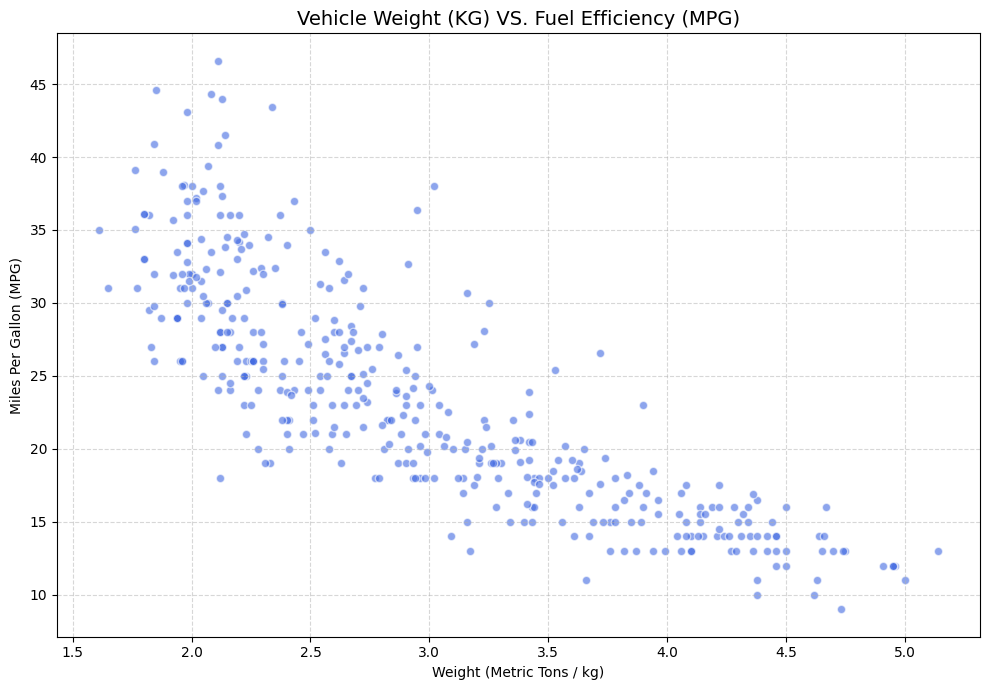

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(mpg_new['weight(kg)'], mpg_new['mpg'], alpha=0.6, color='royalblue', edgecolors='white')

# Formatting
plt.title('Vehicle Weight (KG) VS. Fuel Efficiency (MPG)', fontsize=14)
plt.xlabel('Weight (Metric Tons / kg)', fontsize=10)
plt.ylabel('Miles Per Gallon (MPG)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Average Fuel Efficiency (MPG) Trend by Region (1970-1982)
All three regions show an upward trend in efficiency, but Japan and Europe consistently maintained higher MPG than the USA.

In [ ]:
plt.figure(figsize=(10, 5))
colors = {'usa': 'firebrick', 'japan': 'forestgreen', 'europe': 'royalblue'}

# Group by year and origin to get the average MPG
for origin in ['usa', 'japan', 'europe']:
    subset = mpg_new[mpg_new['origin'] == origin]
    yearly_avg = subset.groupby('model_year')['mpg'].mean()
    plt.plot(yearly_avg.index, yearly_avg.values, marker='o', label=origin.upper(), color=colors[origin], linewidth=2)

# Formatting
plt.title('Average Fuel Efficiency (MPG) Trend by Region (1970-1982)', fontsize=14)
plt.xlabel('Model Year (19xx)', fontsize=10)
plt.ylabel('Average Miles Per Gallon (MPG)', fontsize=10)
plt.legend(title='Region of Origin')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

# Evolution of Fuel Efficiency: Average MPG per Year (1970-1982)
This highlights the industry's successful shift toward sustainability and cost-saving technologies in response to global economic pressures.

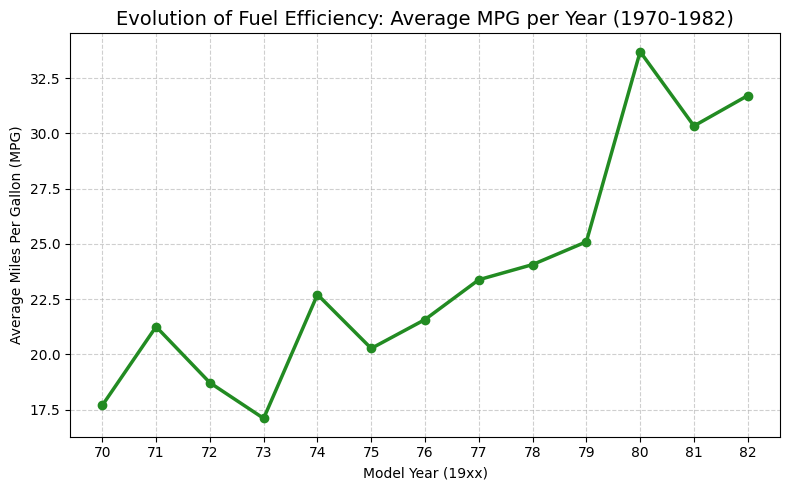

In [ ]:

# Process data: Calculate the Average MPG per year
yearly_avg_mpg = mpg_new.groupby('model_year')['mpg'].mean()

# Create the Line Plot
plt.figure(figsize=(8, 5))
plt.plot(yearly_avg_mpg.index, yearly_avg_mpg.values,
         marker='o', linestyle='-', color='forestgreen', linewidth=2.5)

# Formatting
plt.title('Evolution of Fuel Efficiency: Average MPG per Year (1970-1982)', fontsize=14)
plt.xlabel('Model Year (19xx)', fontsize=10)
plt.ylabel('Average Miles Per Gallon (MPG)', fontsize=10)
plt.xticks(yearly_avg_mpg.index)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()